In [ ]:
from huggingface_hub import hf_hub_download
hf_hub_download(repo_id="benmoseley/ese-dl-2024-25-group-project", filename="train.h5", repo_type="dataset", local_dir="data")
hf_hub_download(repo_id="benmoseley/ese-dl-2024-25-group-project", filename="events.csv", repo_type="dataset", local_dir="data")
import pandas as pd
import h5py
import IPython
import PIL
import matplotlib.pyplot as plt
import os
import io
# this DataFrame contains all of the event meta data
df = pd.read_csv("data/events.csv", parse_dates=["start_utc"])

# this function loads all of the image arrays for a given id
def load_event(id):
    "Load event"
    with h5py.File(f'data/train.h5','r') as f:
        event = {img_type: f[id][img_type][:] for img_type in ['vis', 'ir069', 'ir107', 'vil', 'lght']}
    return event

# import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

# 去重，确保每个事件只保留一行
events = df.drop_duplicates(subset=['id']).copy()

# 时间划分
events['start_date'] = pd.to_datetime(events['start_utc']).dt.date
events['month'] = pd.to_datetime(events['start_utc']).dt.month
events['season'] = events['month'].map({
    12: 'Winter', 1: 'Winter', 2: 'Winter',
    3: 'Spring', 4: 'Spring', 5: 'Spring',
    6: 'Summer', 7: 'Summer', 8: 'Summer',
    9: 'Fall', 10: 'Fall', 11: 'Fall'
})

# 地理区域划分
def assign_region(row):
    if row['llcrnrlat'] > 40:  # 纬度划分
        return 'North'
    elif row['llcrnrlat'] < 30:
        return 'South'
    elif row['llcrnrlon'] < -100:  # 经度划分
        return 'West'
    else:
        return 'East'

events['region'] = events.apply(assign_region, axis=1)

# 分层抽样划分
train_events, val_events = train_test_split(
    events,
    test_size=0.3,  # 验证集比例
    stratify=events[['season', 'region']],  # 按季节和区域分层
    random_state=42
)

val_events, test_events = train_test_split(
    val_events,
    test_size=0.5,  # 测试集比例
    stratify=val_events[['season', 'region']],  # 按季节和区域分层
    random_state=42
)

train_ids = train_events['id']
val_ids = val_events['id']
test_ids = test_events['id']
print(f"训练集大小: {len(train_ids)}")
print(f"验证集大小: {len(val_ids)}")
print(f"测试集大小: {len(test_ids)}")


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


训练集大小: 560
验证集大小: 120
测试集大小: 120


In [ ]:
import torch
import torch.nn.functional as F
import numpy as np

def process_data(event_ids):

    # 预定义数据大小（假设 N 是已知的）
    N = len(event_ids)
    H, W = 384, 384
    input_channels = 108  # 3 通道的时间序列长度 36
    target_channels = 36  # vil 时间序列 36

    # 直接分配 tensor 避免 list append
    data_inputs = torch.empty((N, input_channels, H, W), dtype=torch.float32)
    data_targets = torch.empty((N, target_channels, H, W), dtype=torch.float32)

    for i, id in enumerate(event_ids):
        event = load_event(id)

        # 读取数据并转换为 Tensor
        vis = torch.from_numpy(event['vis'].astype(np.float32)).permute(2, 0, 1)  # (36, 384, 384)
        ir069 = torch.from_numpy(event['ir069'].astype(np.float32)).permute(2, 0, 1)  # (36, 原始 H, W)
        ir107 = torch.from_numpy(event['ir107'].astype(np.float32)).permute(2, 0, 1)  # (36, 原始 H, W)
        vil = torch.from_numpy(event['vil'].astype(np.float32)).permute(2, 0, 1)  # (36, 384, 384)

        # 上采样红外数据到 384x384
        ir069 = F.interpolate(ir069.unsqueeze(0), size=(H, W), mode='bilinear', align_corners=False).squeeze(0)
        ir107 = F.interpolate(ir107.unsqueeze(0), size=(H, W), mode='bilinear', align_corners=False).squeeze(0)

        # 归一化
        def normalize(tensor):
            min_val = tensor.min(dim=1, keepdim=True)[0].min(dim=2, keepdim=True)[0]  # 只计算一次 min
            max_val = tensor.max(dim=1, keepdim=True)[0].max(dim=2, keepdim=True)[0]  # 只计算一次 max
            return (tensor - min_val) / (max_val - min_val + 1e-8)  # 避免除零错误

        vis = normalize(vis)
        ir069 = normalize(ir069)
        ir107 = normalize(ir107)
        vil = normalize(vil)

        # 合并输入通道 (108, 384, 384)
        inputs = torch.cat([vis, ir069, ir107], dim=0)

        # 存入预分配张量
        data_inputs[i] = inputs
        data_targets[i] = vil

        if (i + 1) % 10 == 0:
            print(f"Processed {i+1}/{N}")
    return data_inputs, data_targets
train_inputs, train_targets = process_data(train_ids)
val_inputs, val_targets = process_data(val_ids)
test_inputs, test_targets = process_data(test_ids)
# 检查最终形状
print("Final Input Shape:", train_inputs.shape, "Final Target Shape:", train_targets.shape)
print("Final Input Shape:", val_inputs.shape, "Final Target Shape:", val_targets.shape)
print("Final Input Shape:", test_inputs.shape, "Final Target Shape:", test_targets.shape)


Processed 10/560
Processed 20/560
Processed 30/560
Processed 40/560
Processed 50/560
Processed 60/560
Processed 70/560
Processed 80/560
Processed 90/560
Processed 100/560
Processed 110/560
Processed 120/560
Processed 130/560
Processed 140/560
Processed 150/560
Processed 160/560
Processed 170/560
Processed 180/560
Processed 190/560
Processed 200/560
Processed 210/560
Processed 220/560
Processed 230/560
Processed 240/560
Processed 250/560
Processed 260/560
Processed 270/560
Processed 280/560
Processed 290/560
Processed 300/560
Processed 310/560
Processed 320/560
Processed 330/560
Processed 340/560
Processed 350/560
Processed 360/560
Processed 370/560
Processed 380/560
Processed 390/560
Processed 400/560
Processed 410/560
Processed 420/560
Processed 430/560
Processed 440/560
Processed 450/560
Processed 460/560
Processed 470/560
Processed 480/560
Processed 490/560
Processed 500/560
Processed 510/560
Processed 520/560
Processed 530/560
Processed 540/560
Processed 550/560
Processed 560/560
P

In [ ]:
from itertools import cycle
from scipy.ndimage import zoom
import numpy as np
import h5py

def upsample(data, target_shape=(384, 384, 36)):
    """
    Upsample data to target resolution.
    :param data: Original data, shape (height, width).
    :param target_shape: Target resolution (height, width).
    :return: Upsampled data.
    """
    zoom_factors = (target_shape[0] / data.shape[0], target_shape[1] / data.shape[1],target_shape[2] / data.shape[2])
    return zoom(data, zoom_factors, order=1)

def extract_event_ids(file_path):
    """
    Extract all event IDs from the HDF5 file.
    :param file_path: HDF5 file path.
    :return: List of event IDs.
    """
    with h5py.File(file_path, "r") as f:
        return list(f.keys())

def standard_normalize(data):
    """
    Standard normalization: (data - mean) / std.
    Avoid division by zero by adding a small epsilon to std.
    """
    mean = np.mean(data)
    std = np.std(data)
    return (data - mean) / (std + 1e-8)

def dynamic_data_generator(file_path, event_ids, batch_size=8, input_length=12, output_length=12, target_shape=(384, 384, 36)):
    """
    Dynamically loads and processes data from HDF5 file for training and validation,
    with added standard normalization.
    """
    event_cycle = cycle(event_ids)
    np.random.shuffle(event_ids)

    with h5py.File(file_path, "r") as f:
        while True:
            X_batch, Y_batch = [], []

            unique_event_ids = [next(event_cycle) for _ in range(batch_size)]

            for event_id in unique_event_ids:
                if event_id not in f:
                    raise ValueError(f"Event ID {event_id} not found in file.")

                # Load all datasets
                vis = f[event_id]["vis"][:]
                ir069 = f[event_id]["ir069"][:]
                ir107 = f[event_id]["ir107"][:]
                vil = f[event_id]["vil"][:]

                # Standardize each dataset
                #vis = standard_normalize(vis)
                #ir069 = standard_normalize(ir069)
                #ir107 = standard_normalize(ir107)
                #vil = standard_normalize(vil)



                # Upsample and stack inputs
                X_resized = np.stack([
                        upsample(vis, target_shape),
                        upsample(ir069, target_shape),
                        upsample(ir107, target_shape),

                    ])
                # Shape: (input_length, height, width, channels)

               # Reshape X_resized to (height, width, input_length * 4)
                X_combined = X_resized.transpose((1, 2, 0, 3)).reshape(target_shape[0], target_shape[1], -1)

                # Upsample outputs
                Y_resized = np.array([
                    upsample(vil, target_shape)

                ])  # Shape: (output_length, height, width)

                # Reshape Y_resized to (height, width, output_length)
                Y_combined = Y_resized.transpose((1, 2, 0, 3)).reshape(target_shape[0], target_shape[1], -1)



                X_batch.append(X_combined)
                Y_batch.append(Y_combined)

            yield np.array(X_batch), np.array(Y_batch)

In [ ]:
import numpy as np
import tensorflow as tf

def dynamic_data_generator(file_path, data_inputs, data_targets, batch_size=8, input_length=12, output_length=12, target_shape=(384, 384, 36)):



    num_samples = data_inputs.shape[0]  # Total number of events/samples

    while True:
        indices = np.random.permutation(num_samples)  # Shuffle indices each epoch

        for i in range(0, num_samples, batch_size):
            batch_indices = indices[i: i + batch_size]

            X_batch = []
            Y_batch = []

            for idx in batch_indices:
                # Extract `input_length` frames as input
                X_sample = data_inputs[idx]# Shape: (input_length, 384, 384)

                # Extract `output_length` frames as target
                Y_sample = data_targets[idx]   # Shape: (output_length, 384, 384)
                # transpose
                X_sample = np.transpose(X_sample, (1, 2, 0))
                Y_sample = np.transpose(Y_sample, (1, 2, 0))
                X_batch.append(X_sample)
                Y_batch.append(Y_sample)

            # Convert to NumPy arrays with shape (batch_size, time_steps, height, width, channels)
            X_batch = np.array(X_batch)  # Shape: (batch_size, input_length, 384, 384)
            Y_batch = np.array(Y_batch)  # Shape: (batch_size, output_length, 384, 384)
            # change shape

            yield X_batch, Y_batch  # Yield a batch for training


In [ ]:
# Extract event IDs from train.h5
file_path = "data/train.h5"

batch_size = 16
# Create generators
train_generator = dynamic_data_generator(file_path, train_inputs, train_targets, batch_size=batch_size)
val_generator = dynamic_data_generator(file_path, val_inputs, val_targets, batch_size=batch_size)
test_generator = dynamic_data_generator(file_path, test_inputs, test_targets, batch_size=batch_size)

# Check output shape for debugging
X_batch, Y_batch = next(train_generator)
print("Input batch shape:", X_batch.shape)
print("Output batch shape:", Y_batch.shape)

Input batch shape: (16, 384, 384, 108)
Output batch shape: (16, 384, 384, 36)


In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Conv2D, MaxPooling2D, UpSampling2D, Concatenate, Reshape, Flatten
)
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

def unet_with_temporal_encoding(input_shape=(384, 384, 108), output_channels=36):
    """
    U-Net model with temporal encoding for spatiotemporal data.

    :param input_shape: Shape of the input (height, width, channels), where channels = frames * features.
    :param output_channels: Number of output frames to predict.
    :return: Compiled U-Net model.
    """
    # Input layer
    inputs = Input(shape=input_shape, name="input_layer")

    # Encoding path
    conv1 = Conv2D(64, (3, 3), activation='relu', padding='same')(inputs)
    pool1 = MaxPooling2D(pool_size=(2, 2))(conv1)

    conv2 = Conv2D(128, (3, 3), activation='relu', padding='same')(pool1)
    pool2 = MaxPooling2D(pool_size=(2, 2))(conv2)

    conv3 = Conv2D(256, (3, 3), activation='relu', padding='same')(pool2)
    pool3 = MaxPooling2D(pool_size=(2, 2))(conv3)

    # Bottleneck
    conv4 = Conv2D(512, (3, 3), activation='relu', padding='same')(pool3)

    # Decoding path
    up1 = UpSampling2D(size=(2, 2))(conv4)
    concat1 = Concatenate()([up1, conv3])
    conv5 = Conv2D(256, (3, 3), activation='relu', padding='same')(concat1)

    up2 = UpSampling2D(size=(2, 2))(conv5)
    concat2 = Concatenate()([up2, conv2])
    conv6 = Conv2D(128, (3, 3), activation='relu', padding='same')(concat2)

    up3 = UpSampling2D(size=(2, 2))(conv6)
    concat3 = Concatenate()([up3, conv1])
    conv7 = Conv2D(64, (3, 3), activation='relu', padding='same')(concat3)

    # Output layer: Predicting `output_channels` frames with a single output channel each
    outputs = Conv2D(output_channels, (1, 1), activation='linear', padding='same', name="output_layer")(conv7)

    # Define model
    model = Model(inputs=inputs, outputs=outputs)
    #model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    model.compile(optimizer=Adam(learning_rate=1e-4), loss='mse', metrics=['mae'])
    return model

# input layer
input_layer = Input(shape=(384, 384, 108), name="input_layer")  # 108 channel

# U-Net model
model = unet_with_temporal_encoding(input_shape=(384, 384, 108), output_channels=36)


early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=2,
    min_delta=1e-3,
    restore_best_weights=True
)

# training
model.fit(
    train_generator,
    validation_data=val_generator,
    steps_per_epoch=35,
    validation_steps=10,
    epochs=10,
    callbacks=[early_stopping]
)


Epoch 1/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 104s 2s/step - loss: 0.0523 - mae: 0.1507 - val_loss: 0.0341 - val_mae: 0.1033
Epoch 2/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 54s 2s/step - loss: 0.0315 - mae: 0.1022 - val_loss: 0.0311 - val_mae: 0.1040
Epoch 3/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 53s 2s/step - loss: 0.0275 - mae: 0.0982 - val_loss: 0.0290 - val_mae: 0.1111
Epoch 4/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 53s 2s/step - loss: 0.0254 - mae: 0.0972 - val_loss: 0.0264 - val_mae: 0.0968
Epoch 5/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 53s 2s/step - loss: 0.0234 - mae: 0.0932 - val_loss: 0.0259 - val_mae: 0.1033
Epoch 6/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 53s 2s/step - loss: 0.0258 - mae: 0.1009 - val_loss: 0.0248 - val_mae: 0.0997
Epoch 7/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 52s 2s/step - loss: 0.0237 - mae: 0.0961 - val_loss: 0.0247 - val_mae: 0.0994
Epoch 8/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 53s 2s/step - loss: 0.0238 - mae: 0.0953 - val_loss: 0.0242 - val_mae: 0.0947


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 567ms/step


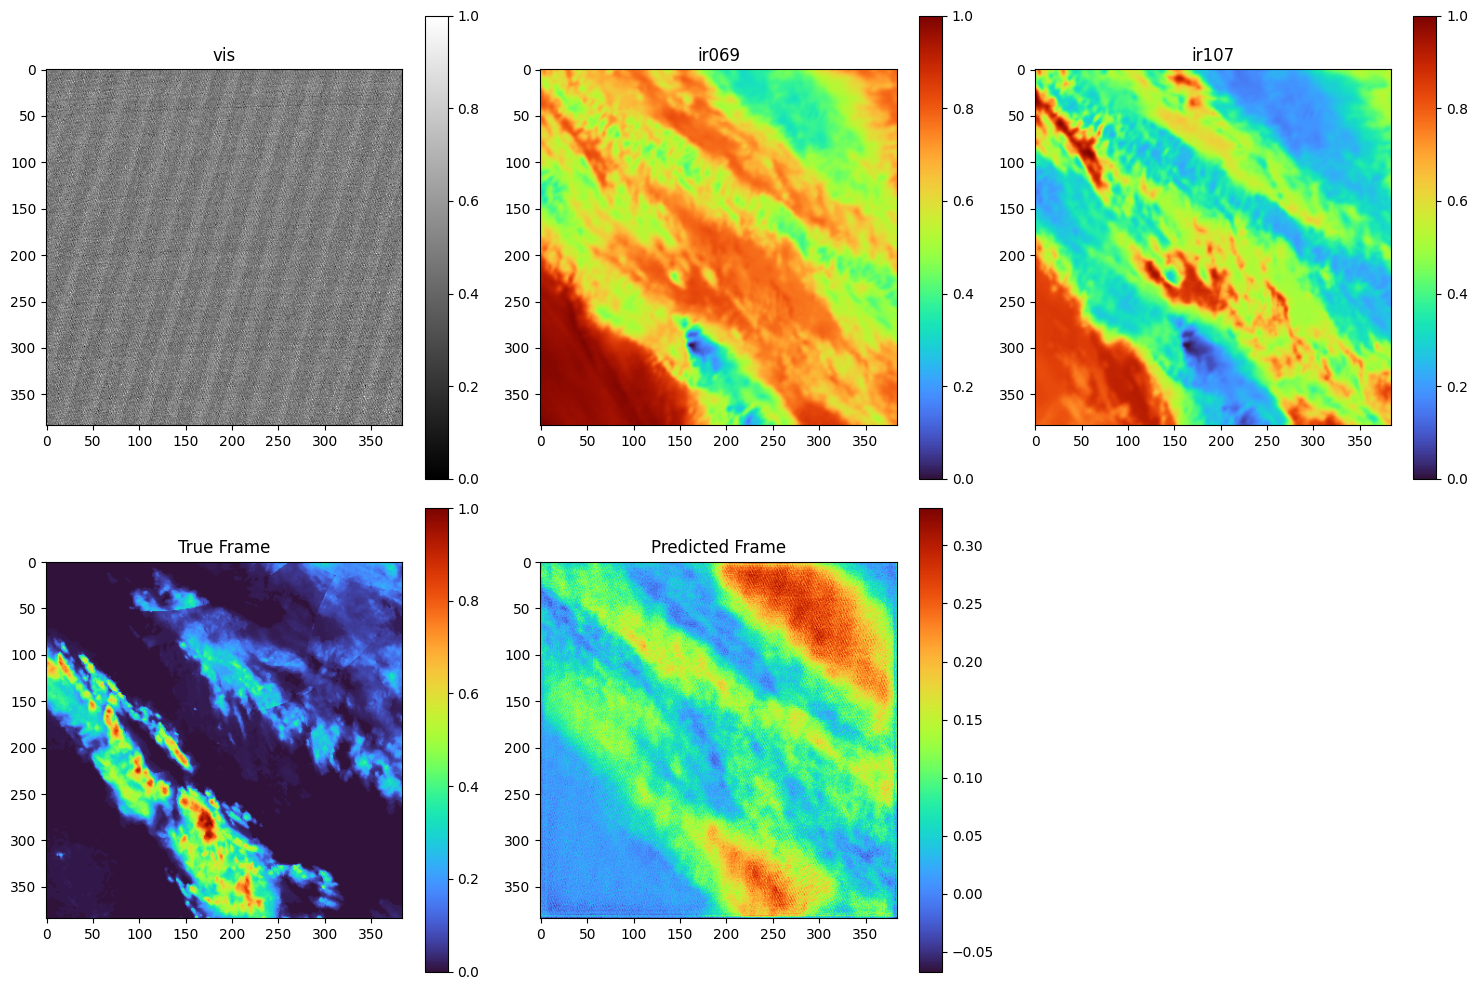

In [ ]:


# Get one batch of test data
X_test, Y_test = next(train_generator)  # Fetch a single batch from the test generator

# Generate predictions
Y_pred = model.predict(X_test)


import matplotlib.pyplot as plt

# Select a frame to visualize, e.g., the first frame in the output sequence
frame_index = 0  # Change this to visualize different frames
example_index = 0  # Select the first example in the batch

# Extract the true and predicted frames
true_frame = Y_test[example_index, :, :, frame_index]
vis = X_test[example_index, :, :, 0]
ir069 = X_test[example_index, :, :, 36]
ir107 = X_test[example_index, :, :, 72]
pred_frame = Y_pred[example_index, :, :, frame_index]
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 3, figsize=(15, 10))  # 2 rows, 3 columns

# Visualizing "vis"
axes[0, 0].set_title("vis")
im0 = axes[0, 0].imshow(vis.squeeze(), cmap="gray")
fig.colorbar(im0, ax=axes[0, 0])

# Visualizing "ir069"
axes[0, 1].set_title("ir069")
im1 = axes[0, 1].imshow(ir069.squeeze(), cmap="turbo")
fig.colorbar(im1, ax=axes[0, 1])

# Visualizing "ir107"
axes[0, 2].set_title("ir107")
im2 = axes[0, 2].imshow(ir107.squeeze(), cmap="turbo")
fig.colorbar(im2, ax=axes[0, 2])

# True frame
axes[1, 0].set_title("True Frame")
im3 = axes[1, 0].imshow(true_frame.squeeze(), cmap="turbo")
fig.colorbar(im3, ax=axes[1, 0])

# Predicted frame
axes[1, 1].set_title("Predicted Frame")
im4 = axes[1, 1].imshow(pred_frame.squeeze(), cmap="turbo")
fig.colorbar(im4, ax=axes[1, 1])

# Remove the empty last subplot (axes[1, 2])
fig.delaxes(axes[1, 2])

plt.tight_layout()
plt.show()


In [ ]:
model.save_weights("tensorflow.weights.h5")

In [ ]:
model.save("tensorflow.model.h5")